# Dynamic Traffic Demo

This notebook explains how the dynamic traffic system works in MetaLore and runs one episode for each of the six traffic profiles.

In a dynamic traffic scenario, **UEs don't all exist for the full episode**. Each UE has:
- a **start time** (`stime`) — the timestep it appears
- an **exit time** (`extime`) — the timestep it leaves

The `DynamicArrival` model is responsible for assigning those times at the start of each episode. It reads from a **TrafficProfile** which controls:

| Parameter | What it controls |
|---|---|
| `pool_size` | Total number of UEs in the episode |
| `arrival_window` | The fraction of the episode during which UEs can arrive (e.g. `(0.0, 0.4)` = first 40 timesteps) |
| `mean_sojourn` | Average number of timesteps a UE stays (drawn from exponential distribution) |
| `job_gen_prob` | Probability of a UE generating a job each timestep |
| `job_data_size` | Mean data size of generated jobs (bits) |
| `job_compute_size` | Mean compute size of generated jobs (cycles) |
| `arrival_type` | `'uniform'` or `'gaussian'` — shape of the arrival curve |
| `burst_*` | Parameters for the Gaussian burst (only used in `burst` profile) |

All six profiles are defined in `metalore/config/profiles.py` and selected at config creation time.

## The six profiles

| Profile | Pool | Arrival window | Mean sojourn | Character |
|---|---|---|---|---|
| `low` | 15 | 0% – 80% | 70 steps | Sparse, wide arrival window, long sojourn |
| `medium` | 25 | 0% – 50% | 80 steps | Balanced load, long sojourn |
| `high` | 40 | 0% – 20% | 90 steps | Heavy, early arrivals, near-full episode |
| `ramp_up` | 30 | 20% – 90% | 75 steps | Load builds from step 20 onwards |
| `ramp_down` | 30 | 0% – 20% | 35 steps | Crowded start, drains out by end |
| `burst` | 35 | 0% – 90% | 45 steps | Background load + Gaussian surge at midpoint |

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython import display as ipd

from metalore.scenarios import SingleCellEnv
from metalore.config import TRAFFIC_PROFILES
from metalore.config import (
    low_traffic_config,
    medium_traffic_config,
    high_traffic_config,
    ramp_up_traffic_config,
    ramp_down_traffic_config,
    burst_traffic_config,
)

PROFILE_CONFIGS = {
    'low':       low_traffic_config(),
    'medium':    medium_traffic_config(),
    'high':      high_traffic_config(),
    'ramp_up':   ramp_up_traffic_config(),
    'ramp_down': ramp_down_traffic_config(),
    'burst':     burst_traffic_config(),
}

COLORS = {
    'low':       '#4e79a7',
    'medium':    '#f28e2b',
    'high':      '#e15759',
    'ramp_up':   '#76b7b2',
    'ramp_down': '#59a14f',
    'burst':     '#b07aa1',
}

T = 100  # max_steps
print('Profiles loaded:', list(PROFILE_CONFIGS.keys()))

Profiles loaded: ['low', 'medium', 'high', 'ramp_up', 'ramp_down', 'burst']


## Profile parameters

In [2]:
rows = []
for name, p in TRAFFIC_PROFILES.items():
    rows.append({
        'profile':        name,
        'pool_size':      p.pool_size,
        'arrival_window': f'{p.arrival_window[0]:.0%} – {p.arrival_window[1]:.0%}',
        'mean_sojourn':   p.mean_sojourn,
        'job_gen_prob':   p.job_gen_prob,
        'data_size_kbit': p.job_data_size // 1000,
        'compute_Mcyc':   p.job_compute_size // 1_000_000,
        'arrival_type':   p.arrival_type,
    })

pd.DataFrame(rows).set_index('profile')

,pool_size,arrival_window,mean_sojourn,job_gen_prob,data_size_kbit,compute_Mcyc,arrival_type
profile,,,,,,,
low,15,0% – 80%,70.0,0.6,500,500,uniform
medium,25,0% – 50%,80.0,0.8,1000,1000,uniform
high,40,0% – 20%,90.0,0.9,2000,2000,uniform
ramp_up,30,20% – 90%,75.0,0.8,1500,1500,uniform
ramp_down,30,0% – 20%,35.0,0.7,1000,800,uniform
burst,35,0% – 90%,45.0,0.9,3000,3000,gaussian


## Simulations

Each cell below runs one episode for a single profile with a fixed action `[0.5, 0.5]` (equal bandwidth and compute split). The cell renders the environment and shows:
- **Active UEs over time** — how many UEs are present at each timestep
- **Cumulative reward** — how reward accumulates over the episode

In [3]:
def run_episode(profile_name, seed=42):
    """Run one episode with rendering. Returns collected metrics."""
    cfg = PROFILE_CONFIGS[profile_name]
    cfg['environment']['seed'] = seed
    cfg['environment']['reset_rng_episode'] = True

    env = SingleCellEnv(config=cfg)
    obs, _ = env.reset()

    rewards, active_ues = [], []
    done = False
    c = COLORS[profile_name]
    p = TRAFFIC_PROFILES[profile_name]

    while not done:
        obs, reward, terminated, truncated, info = env.step([0.5, 0.5])
        rewards.append(reward)
        active_ues.append(env.metrics.latest('num_active_ues'))
        done = terminated or truncated

        ipd.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 7))
        ax.imshow(env.render())
        ax.set_title(
            f'Profile: {profile_name}  |  Pool: {p.pool_size} UEs  '
            f'|  Step {len(rewards)}/{T}  |  Reward: {reward:.3f}',
            fontsize=11
        )
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        plt.close()

    ep = env.metrics.finalize(env.job_tracker)
    job_df = env.job_tracker.to_dataframe()
    ue_df  = job_df[job_df['entity_type'] == 'UE'] if len(job_df) > 0 else pd.DataFrame()
    env.close()

    return {
        'rewards':         rewards,
        'active_ues':      active_ues,
        'ep':              ep,
        'ue_df':           ue_df,
        'total_reward':    sum(rewards),
        'peak_active':     max(active_ues),
        'jobs_done':       len(ue_df),
        'throughput_mb':   ue_df['data_size'].sum() / 8e6 if len(ue_df) > 0 else 0.0,
        'completion_rate': ep.get('job_completion_rate', float('nan')),
        'timely_rate':     ep.get('timely_completion_rate', float('nan')),
        'mean_aori':       ep.get('mean_aori', float('nan')),
        'mean_aosi':       ep.get('mean_aosi', float('nan')),
    }

def plot_episode(profile_name, res):
    c = COLORS[profile_name]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Profile: {profile_name}', fontsize=13, fontweight='bold', color=c)

    ax1.fill_between(range(T), res['active_ues'], alpha=0.25, color=c)
    ax1.plot(res['active_ues'], color=c, lw=2)
    ax1.set_title('Active UEs over time')
    ax1.set_xlabel('Timestep'); ax1.set_ylabel('Active UEs')
    ax1.set_ylim(0, TRAFFIC_PROFILES[profile_name].pool_size + 1)
    ax1.grid(True, alpha=0.3)

    ax2.plot(np.cumsum(res['rewards']), color=c, lw=2)
    ax2.set_title('Cumulative reward')
    ax2.set_xlabel('Timestep'); ax2.set_ylabel('Cumulative reward')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    print(
        f"Total reward: {res['total_reward']:.2f}  |  "
        f"Peak active UEs: {res['peak_active']}  |  "
        f"Jobs done: {res['jobs_done']}  |  "
        f"Completion rate: {res['completion_rate']:.2f}"
    )

### `low` — Sparse load
Pool of 15 UEs arriving uniformly over the first 80 timesteps, with a long mean sojourn of 70 steps. Load is light and spread out across the episode.

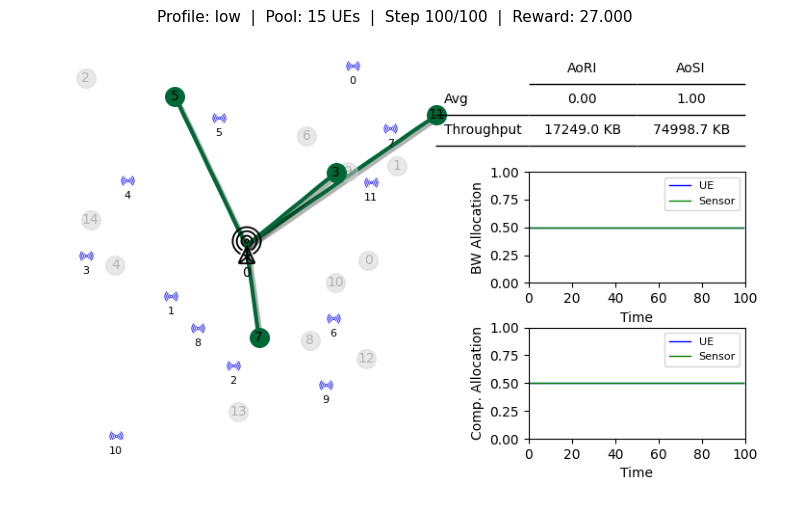

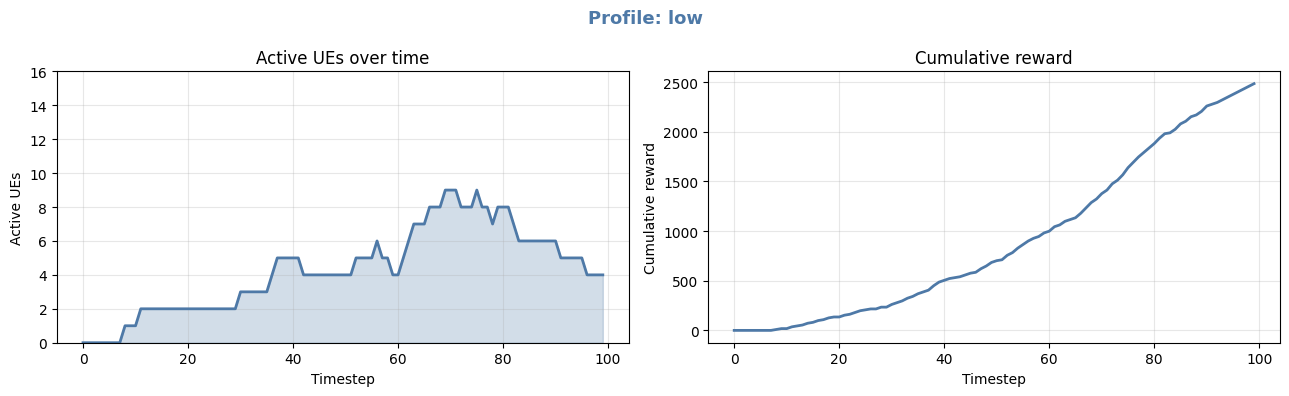

Total reward: 2484.00  |  Peak active UEs: 9  |  Jobs done: 276  |  Completion rate: 1.00


In [4]:
res_low = run_episode('low')
plot_episode('low', res_low)

### `medium` — Balanced load
Pool of 25 UEs arriving uniformly over the first 50 timesteps, with a long sojourn of 80 steps. Most UEs are present for the majority of the episode, creating a steady mid-level load.

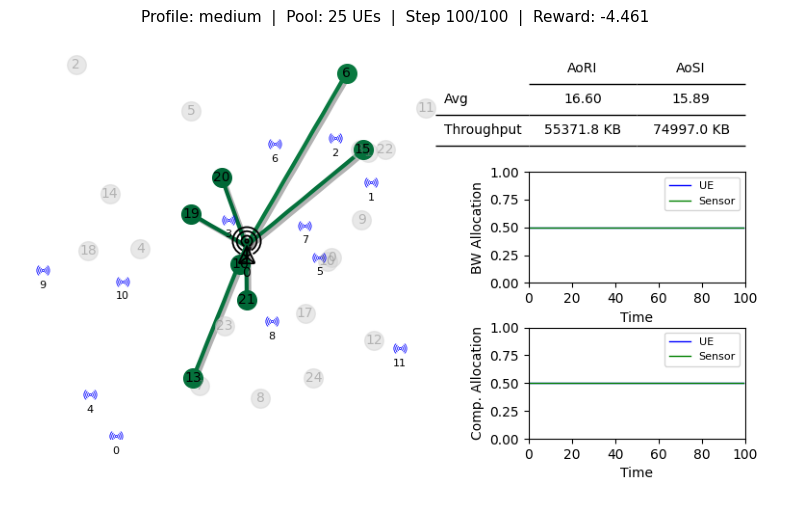

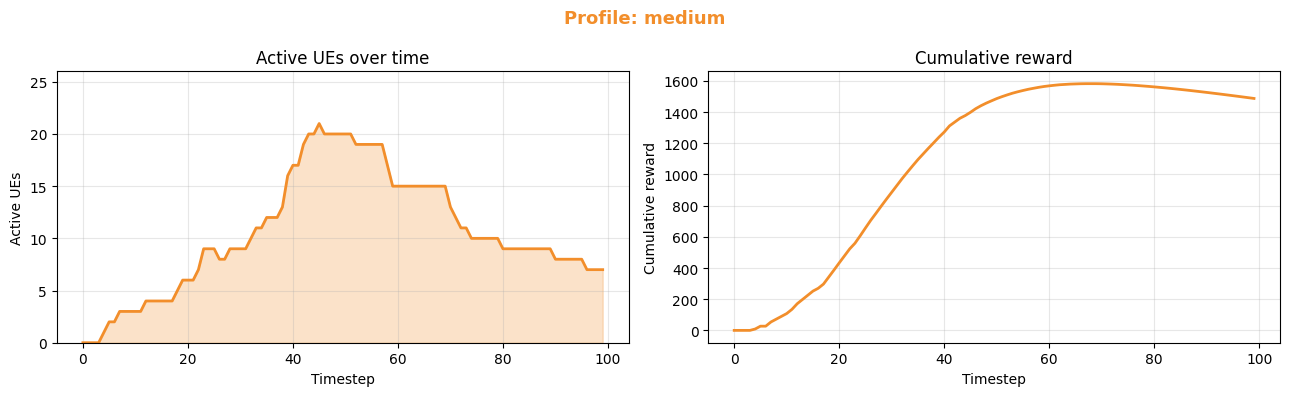

Total reward: 1487.81  |  Peak active UEs: 21  |  Jobs done: 443  |  Completion rate: 0.80


In [5]:
res_medium = run_episode('medium')
plot_episode('medium', res_medium)

### `high` — Heavy load
Large pool of 40 UEs, all arriving in the first 20 timesteps, with a very long sojourn of 90 steps. The system is at near-peak load almost immediately and stays there for the full episode.

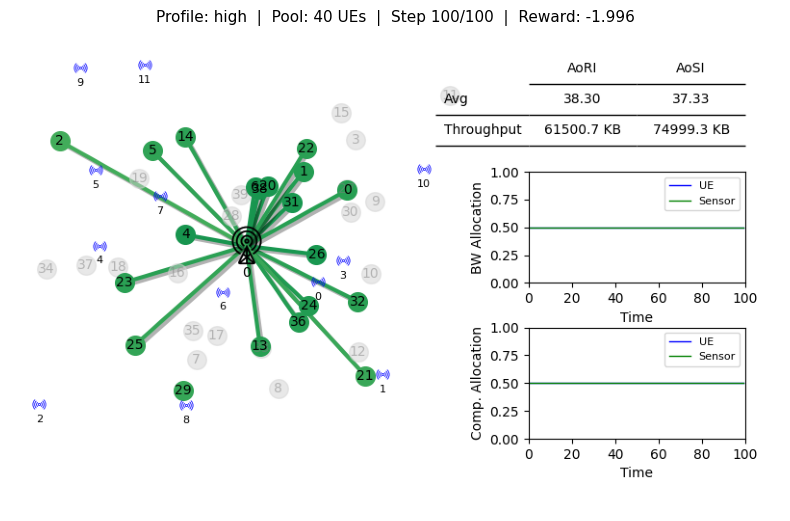

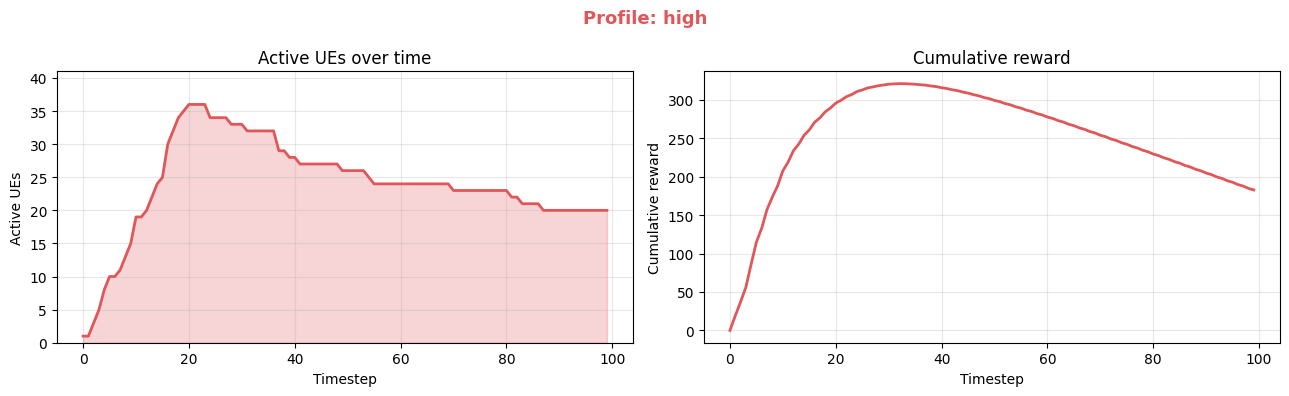

Total reward: 182.82  |  Peak active UEs: 36  |  Jobs done: 246  |  Completion rate: 0.43


In [6]:
res_high = run_episode('high')
plot_episode('high', res_high)

### `ramp_up` — Growing load
Pool of 30 UEs arriving uniformly between steps 20 and 90, with a long sojourn of 75 steps. The system starts quiet then steadily accumulates load through the episode.

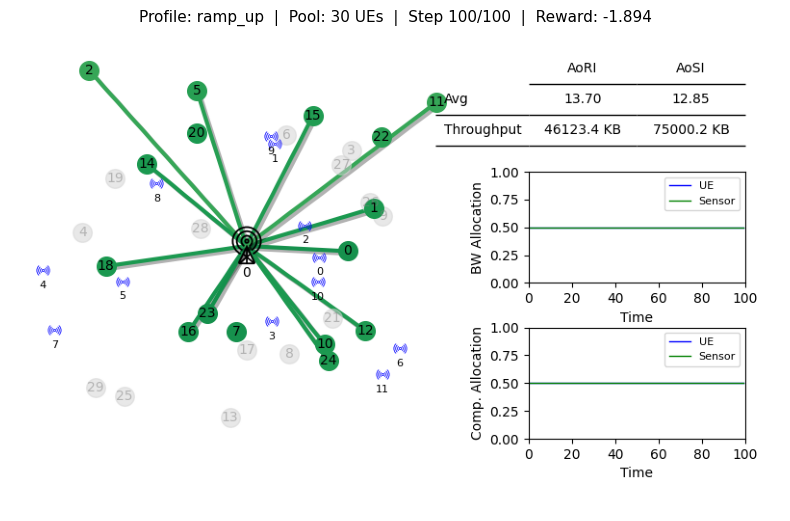

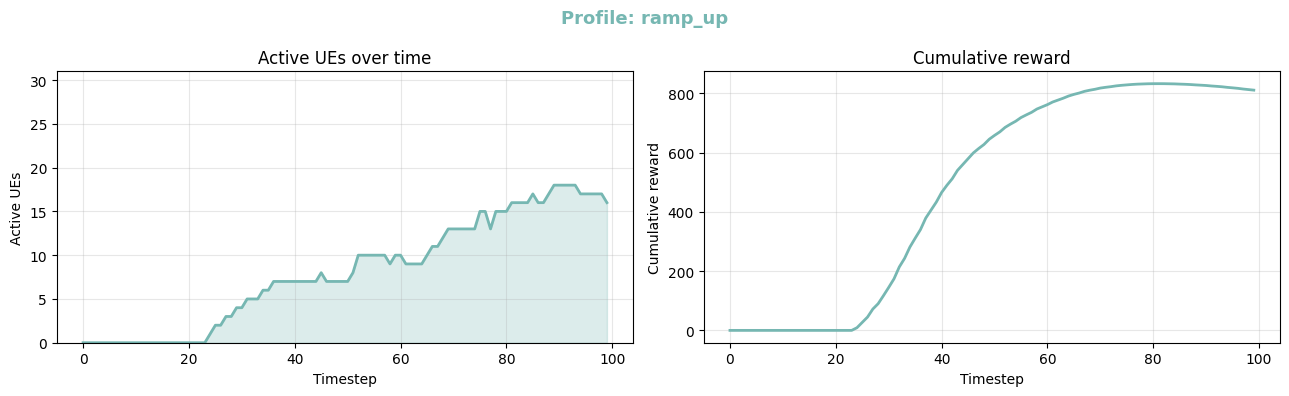

Total reward: 810.72  |  Peak active UEs: 18  |  Jobs done: 246  |  Completion rate: 0.78


In [7]:
res_ramp_up = run_episode('ramp_up')
plot_episode('ramp_up', res_ramp_up)

### `ramp_down` — Draining load
All UEs arrive early but have a short sojourn. The cell is crowded at the start and empties out by episode end.

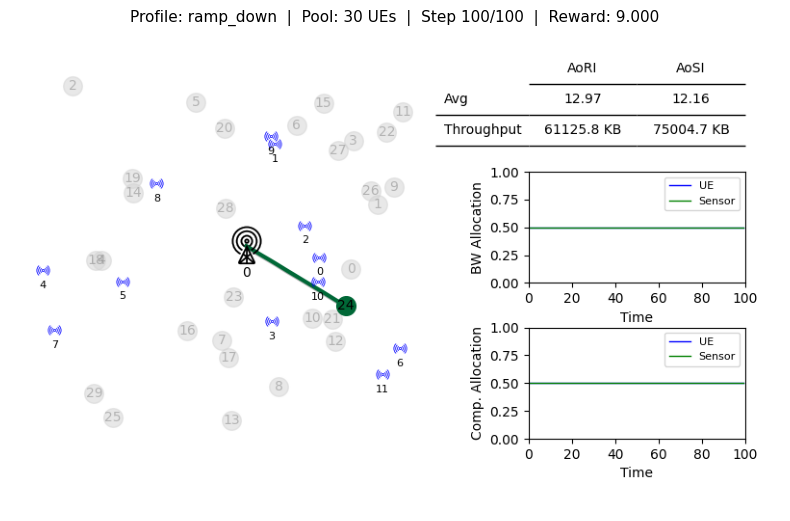

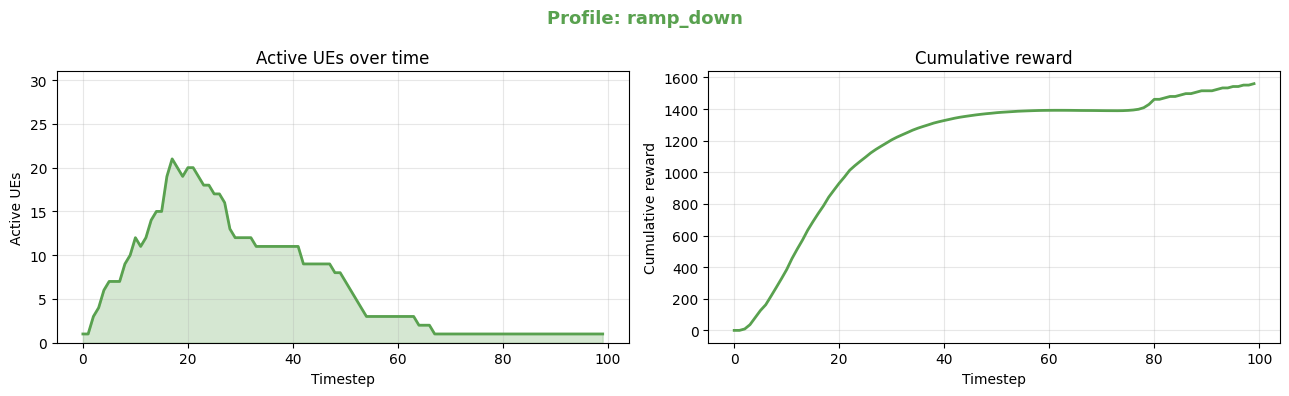

Total reward: 1560.83  |  Peak active UEs: 21  |  Jobs done: 489  |  Completion rate: 1.00


In [8]:
res_ramp_down = run_episode('ramp_down')
plot_episode('ramp_down', res_ramp_down)

### `burst` — Bursty load
Two sub-groups: a background of uniformly-arriving UEs and a Gaussian cluster that all arrive around the midpoint of the episode, creating a sudden spike.

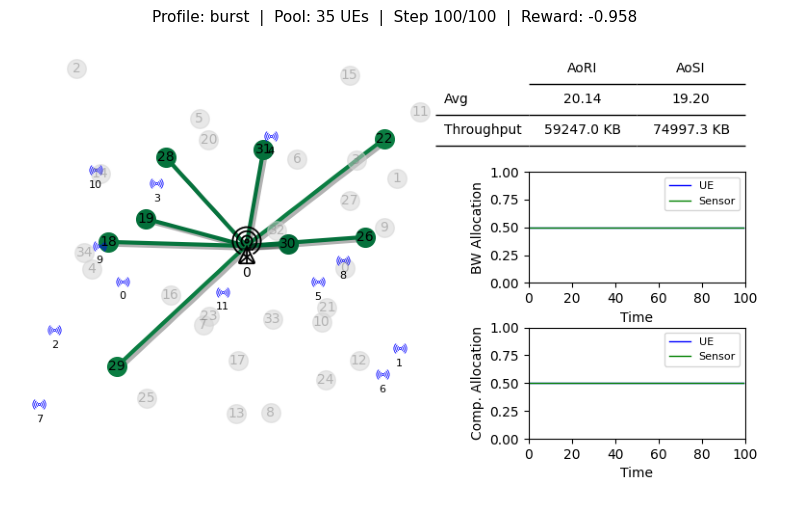

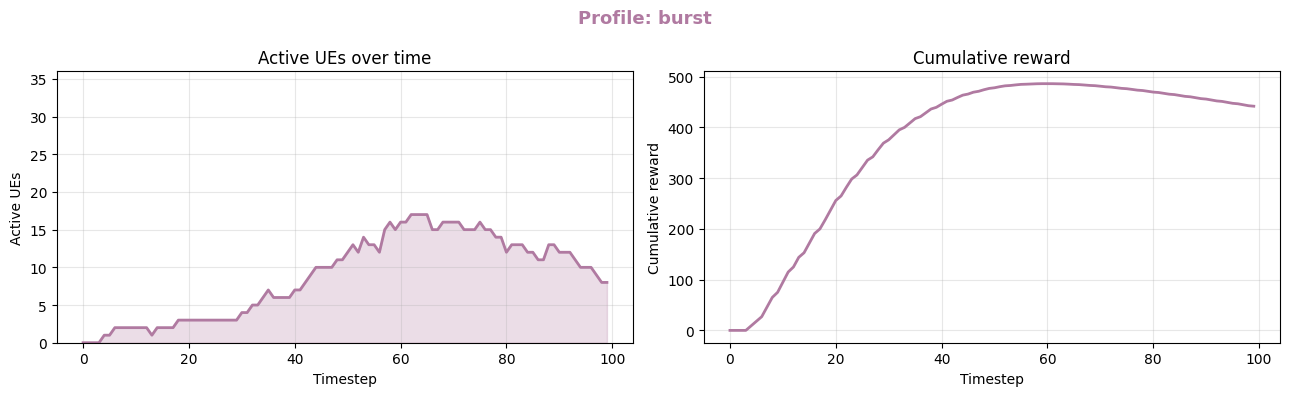

Total reward: 441.87  |  Peak active UEs: 17  |  Jobs done: 158  |  Completion rate: 0.68


In [9]:
res_burst = run_episode('burst')
plot_episode('burst', res_burst)

## All profiles comparison

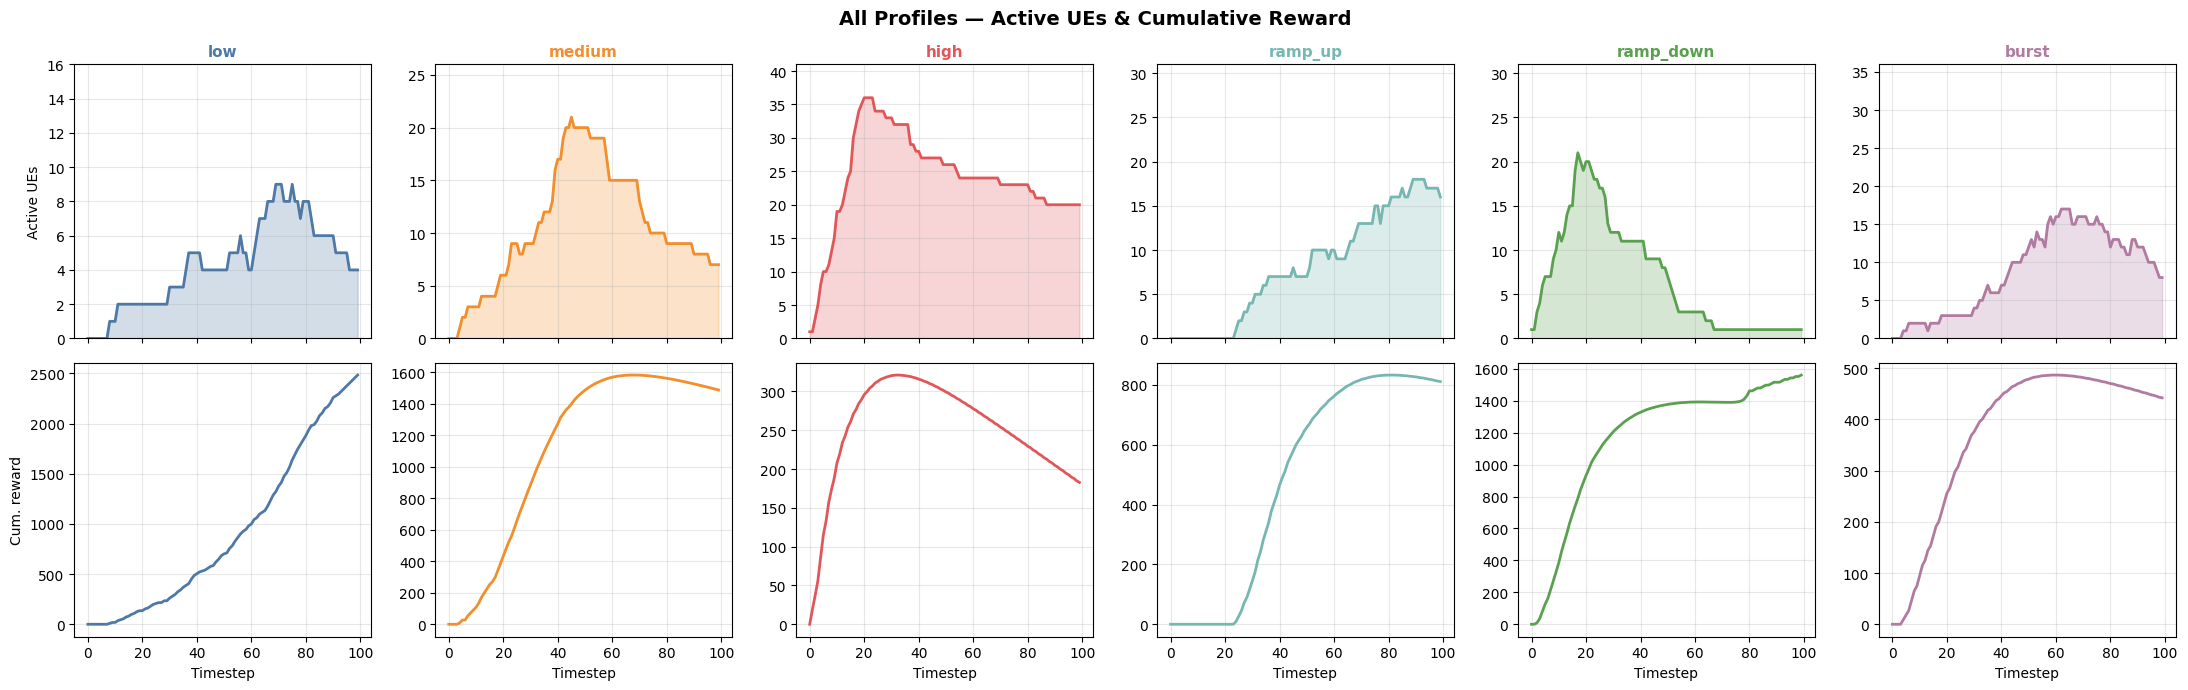

In [10]:
results = {
    'low':       res_low,
    'medium':    res_medium,
    'high':      res_high,
    'ramp_up':   res_ramp_up,
    'ramp_down': res_ramp_down,
    'burst':     res_burst,
}

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle('All Profiles — Active UEs & Cumulative Reward', fontsize=14, fontweight='bold')

for col, (name, res) in enumerate(results.items()):
    c = COLORS[name]
    ax_ue  = axes[0, col]
    ax_rew = axes[1, col]

    ax_ue.fill_between(range(T), res['active_ues'], alpha=0.25, color=c)
    ax_ue.plot(res['active_ues'], color=c, lw=2)
    ax_ue.set_title(name, fontsize=11, fontweight='bold', color=c)
    ax_ue.set_ylim(0, TRAFFIC_PROFILES[name].pool_size + 1)
    ax_ue.set_ylabel('Active UEs' if col == 0 else '')
    ax_ue.grid(True, alpha=0.3)
    ax_ue.tick_params(labelbottom=False)

    ax_rew.plot(np.cumsum(res['rewards']), color=c, lw=2)
    ax_rew.set_xlabel('Timestep')
    ax_rew.set_ylabel('Cum. reward' if col == 0 else '')
    ax_rew.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
summary = []
for name, res in results.items():
    summary.append({
        'profile':         name,
        'total_reward':    round(res['total_reward'], 2),
        'peak_active_ues': res['peak_active'],
        'jobs_done':       res['jobs_done'],
        'throughput_MB':   round(res['throughput_mb'], 3),
        'completion_rate': round(res['completion_rate'], 3),
        'timely_rate':     round(res['timely_rate'], 3),
        'mean_aori':       round(res['mean_aori'], 2),
        'mean_aosi':       round(res['mean_aosi'], 2),
    })

pd.DataFrame(summary).set_index('profile')

,total_reward,peak_active_ues,jobs_done,throughput_MB,completion_rate,timely_rate,mean_aori,mean_aosi
profile,,,,,,,,
low,2484.00,9,276,17.249,1.000,1.000,0.00,1.00
medium,1487.81,21,443,55.372,0.801,0.725,16.60,15.89
high,182.82,36,246,61.501,0.431,0.699,38.30,37.33
ramp_up,810.72,18,246,46.123,0.784,0.752,13.70,12.85
ramp_down,1560.83,21,489,61.126,1.000,0.581,12.97,12.16
burst,441.87,17,158,59.247,0.680,0.627,20.14,19.20
